# Photonic interference beyond 1-WL: three models on the same graphs

This notebook is proposal B of
[rel-int/optyx#16](https://github.com/rel-int/optyx/pull/16): a
*separation* rather than a benchmark. We generate pairs of
non-isomorphic graphs that classical message passing provably cannot
tell apart — the 1-WL bound of
[Xu et al., ICLR 2019](https://arxiv.org/abs/1810.00826) and
[Morris et al., AAAI 2019](https://arxiv.org/abs/1810.02244) — and run
three models on them:

1. **a vanilla GNN**: the textbook isotropic message-passing network —
   one hidden vector per vertex, one shared message function, sum
   aggregation over neighbours, mean readout over vertices;
2. **a MapNN from `discopy.neural`**
   ([discopy/discopy#585](https://github.com/discopy/discopy/pull/585)):
   the same graphs interpreted as interaction maps — the wiring is a
   closed diagram, one shared cell fills every vertex, and the geometry
   of interaction executes the message passing;
3. **an `optyx.interaction.CMap` whose nodes are interferometers with
   coherent memory and coherent messages**: one cell per vertex with one
   `qmode` port per incident edge, a `qmode` internal memory, a
   beam-splitter tap into a prediction mode, and a single photon
   injected through the initial memory.

Every readout is invariant under graph isomorphism, so a nonzero
separation on a 1-WL-equivalent pair certifies a graph invariant beyond
1-WL. The experiment code is in
[`examples/beyond_1wl.py`](beyond_1wl.py) and its tests in
`test/test_beyond_1wl.py`.

**Requirements**: models 1 and 2 need `torch`, and model 2 needs the
`discopy.neural` of discopy#585 (available on the discopy branch
`claude/proposal-b-three-models-awc5sc`, which also works for the whole
of optyx). Model 3 runs on optyx's pinned discopy alone.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import beyond_1wl as b

## The graph pairs, and the 1-WL certificate

The minimal generated pair is two triangles against a hexagon — both
2-regular, so colour refinement assigns identical colours forever. Then
two hexagons against a 12-cycle, the pair proposed in the PR; decalin
against bicyclopentyl, the 10-vertex chemistry pair of
[Sato's survey](https://arxiv.org/abs/2003.04078); and the 4x4 rook's
graph against the Shrikhande graph, strongly regular with the same
parameters srg(16, 6, 2, 2), which even 3-WL cannot separate. The
control pair — a hexagon against a path — is distinguished by 1-WL, so
any model that fails on *it* is broken rather than bounded.

The indistinguishability is asserted, not asserted-in-prose: for every
pair we check that the stable 1-WL colourings agree and that the graphs
are not isomorphic.

In [2]:
for name, (left, right) in b.PAIRS.items():
    left_nx, right_nx = (nx.Graph(
        [(u, v) for u, nbrs in enumerate(graph) for v in nbrs])
        for graph in (left, right))
    print(f"{name:26}  1-WL equivalent: {b.wl_equivalent(left, right)!s:5}"
          f"  isomorphic: {nx.is_isomorphic(left_nx, right_nx)}")
print(f"{'C6 vs P6 (control)':26}  1-WL equivalent: "
      f"{b.wl_equivalent(*b.CONTROL)}")

2C3 vs C6                   1-WL equivalent: True   isomorphic: False
2C6 vs C12                  1-WL equivalent: True   isomorphic: False
decalin vs bicyclopentyl    1-WL equivalent: True   isomorphic: False
rook vs shrikhande          1-WL equivalent: True   isomorphic: False
C6 vs P6 (control)          1-WL equivalent: False


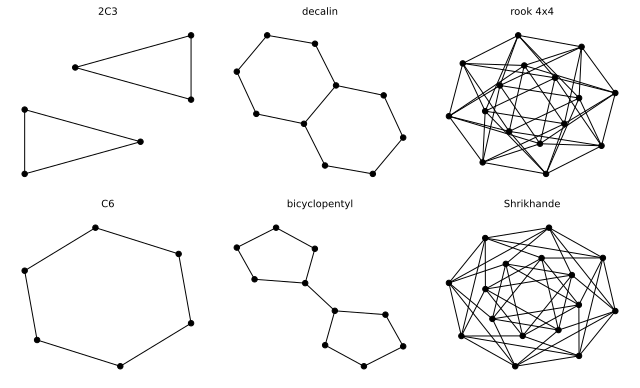

In [3]:
figure, axes = plt.subplots(2, 3, figsize=(9, 5.5))
for axis, (title, graph) in zip(axes.T.flat, [
        ("2C3", b.PAIRS["2C3 vs C6"][0]), ("C6", b.PAIRS["2C3 vs C6"][1]),
        ("decalin", b.PAIRS["decalin vs bicyclopentyl"][0]),
        ("bicyclopentyl", b.PAIRS["decalin vs bicyclopentyl"][1]),
        ("rook 4x4", b.PAIRS["rook vs shrikhande"][0]),
        ("Shrikhande", b.PAIRS["rook vs shrikhande"][1])]):
    edges = nx.Graph([(u, v) for u, ns in enumerate(graph) for v in ns])
    nx.draw_kamada_kawai(edges, ax=axis, node_size=30, node_color="black")
    axis.set_title(title, fontsize=10)
plt.tight_layout()

## Model 1: the vanilla GNN observes the 1-WL bound

The bound is a theorem, but here it is also a measurement. We evaluate
a randomly initialised network — anonymous constant inputs, shared
weights, permutation-invariant readout — and record the largest
difference between the embeddings of the two graphs of each pair, over
independent parameter draws. On 1-WL-equivalent graphs the two
computations perform the same multiset of arithmetic operations, so the
separation is zero to machine precision — below `1e-14` in double
precision, exactly zero for the MapNN, whose compiled interaction also
fixes the summation order — while the control pair separates at every
draw. Training cannot rescue a model
whose forward pass is identically equal on the two classes, so no
training loop is needed for the negative result.

In [4]:
rows = list(b.PAIRS.items())[:3] + [("C6 vs P6 (control)", b.CONTROL)]
for name, (left, right) in rows:
    gap = b.embedding_separation(b.vanilla_gnn_embedding, left, right)
    print(f"{name:26}  max |emb(G1) - emb(G2)| over 5 draws: {gap}")

2C3 vs C6                   max |emb(G1) - emb(G2)| over 5 draws: 2.6645352591003757e-15
2C6 vs C12                  max |emb(G1) - emb(G2)| over 5 draws: 8.881784197001252e-16
decalin vs bicyclopentyl    max |emb(G1) - emb(G2)| over 5 draws: 4.440892098500626e-16
C6 vs P6 (control)          max |emb(G1) - emb(G2)| over 5 draws: 1.3030212397589596


## Model 2: the MapNN observes the same bound

The MapNN pipeline of `discopy.neural` compiles a diagram and one
shared learnable cell per generator name into a global interaction —
the geometry-of-interaction execution formula — and a solver iterates
it. `from_relation` turns each graph into a closed wiring: one `cell`
box per vertex with one `peer` port per neighbour (a permutation
orbit, pooled with `sum`) and a traced `state` loop as its memory.

The wiring is *port-addressed* — each neighbour arrives on its own
wire — but the cell pools its peer orbit with a permutation-invariant
sum and broadcasts one belief, as its signature demands. The whole
model is therefore still anonymous message passing, and lands exactly
on the 1-WL bound. (The `per_leg` emission of `discopy.neural.Site`
answers each port separately; it can produce nonzero separations here,
but they depend on the *ordering* of each adjacency list, which no
graph invariant may do — the same caveat the sudoku comparison of
[discopy#416](https://github.com/discopy/discopy/pull/416) did not
need, because there the ports carried a genuine geometric labelling.)

In [5]:
for name, (left, right) in rows:
    gap = b.embedding_separation(b.mapnn_embedding, left, right)
    print(f"{name:26}  max |emb(G1) - emb(G2)| over 5 draws: {gap}")

2C3 vs C6                   max |emb(G1) - emb(G2)| over 5 draws: 0.0


2C6 vs C12                  max |emb(G1) - emb(G2)| over 5 draws: 0.0
decalin vs bicyclopentyl    max |emb(G1) - emb(G2)| over 5 draws: 0.0


C6 vs P6 (control)          max |emb(G1) - emb(G2)| over 5 draws: 0.5577855706214905


## Model 3: the photonic map separates

One `interaction.Box` per vertex: `degree` message ports, one coherent
`qmode` memory, one prediction. The channel is an interferometer — a
*star coupler*, the memory mode coupled equally to every port and the
ports mixed symmetrically, so the cell is invariant under port
permutations and the readout is a genuine graph invariant (checked
below) — followed by a beam-splitter tap that leaks memory amplitude
into a fresh vacuum mode, the prediction. Any such interferometer
decomposes into beam splitters and phase shifters
(Reck et al., PRL 73, 58 (1994)).

The `CMap` pairs the matching ports of adjacent vertices; all ports are
paired, so the protocol's only output is the prediction stream. A
single photon starts in one vertex's memory and the readout is the
*escape-time profile*: the probability that the photon leaves through a
prediction tap at each tick, for every starting vertex, sorted — a
multiset over vertices, hence isomorphism-invariant.

One tick of the triangle map, and its protocol with the feedback loop:

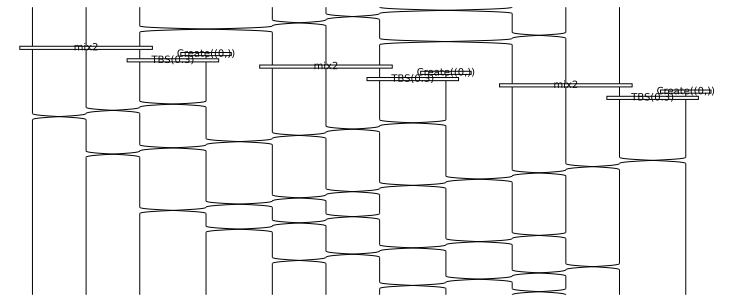

In [6]:
cmap = b.graph_cmap(b.cycle(3))
cmap.step.draw(figsize=(10, 4), wire_labels=False)

Since the diagram is linear-optical and hosts exactly one photon, the
one-photon block of the step's path matrix
(`optyx.core.path.Matrix`, rows split into leak and feedback) iterates
the whole unrolled tensor network exactly — the doubled quimb
contraction of `CMap.unroll` agrees to machine precision
(`test_unrolling_matches_the_path_iteration`), it is just exponentially
more expensive in the number of prediction wires.

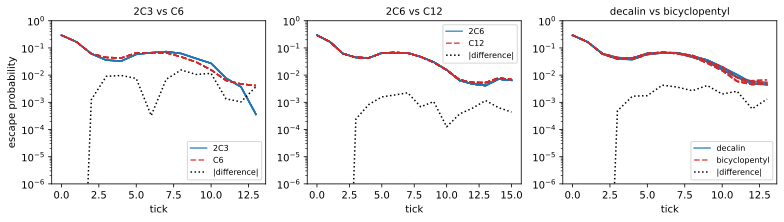

In [7]:
figure, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=False)
for axis, (name, n_ticks) in zip(axes, [
        ("2C3 vs C6", 14), ("2C6 vs C12", 16),
        ("decalin vs bicyclopentyl", 14)]):
    left, right = b.PAIRS[name]
    curves = b.escape_curves(left, n_ticks), b.escape_curves(right, n_ticks)
    for graph_curves, style, label in zip(
            curves, ("-", "--"), name.split(" vs ")):
        for row, curve in enumerate(graph_curves):
            axis.plot(curve, style, color="C0" if style == "-" else "C3",
                      alpha=.8, label=label if row == 0 else None)
    gap = np.abs(curves[0] - curves[1]).max(axis=0)
    axis.plot(gap, ":", color="black", label="|difference|")
    axis.set_title(name, fontsize=10)
    axis.set_xlabel("tick")
    axis.set_yscale("log"); axis.set_ylim(1e-6, 1)
    axis.legend(fontsize=8)
axes[0].set_ylabel("escape probability")
plt.tight_layout()

The curves of a pair coincide exactly until the photon has had time to
interfere with itself around a cycle — tick 2 for girth 3, tick 3 for
girth 6 — and stay apart from then on: the separation *is* the
interference of closed walks, as the sum-over-paths reading predicts.
Against shot noise: estimating each per-tick probability to
five standard deviations below needs of order `(5 / margin)^2` runs
per starting vertex.

In [8]:
for name, (left, right) in list(b.PAIRS.items())[:3]:
    margin = b.separation(left, right, 14)
    print(f"{name:26}  margin: {margin:.5f}   "
          f"shots for 5 sigma: {b.shots_to_separate(margin):,.0f}")
print(f"{'C6 vs P6 (control)':26}  margin: "
      f"{b.separation(*b.CONTROL, 14):.5f}")

2C3 vs C6                   margin: 0.01553   shots for 5 sigma: 103,672


2C6 vs C12                  margin: 0.00224   shots for 5 sigma: 4,976,361


decalin vs bicyclopentyl    margin: 0.00429   shots for 5 sigma: 1,358,135


C6 vs P6 (control)          margin: 0.01350


## The controlled ablation: decoherence erases the separation

Running the *same* network with the photon measured at every tick
replaces the step's amplitudes by the stochastic matrix of their
squared moduli: a classical random walk through the same wiring, with
the same aggregated readout. It still separates the control pair — the
instrument is not broken — but on every 1-WL-equivalent pair it is
*exactly* blind: classical probability mass moves through a regular
graph at rates that depend only on the degrees, and the aggregate
escape curve forgets where the mass sits. The coherent phases that
survive aggregation are precisely what the quantum network adds, and
they are the entire separation.

In [9]:
for name, (left, right) in rows:
    gap = b.separation(left, right, 14, decohered=True)
    print(f"{name:26}  decohered separation: {gap}")

2C3 vs C6                   decohered separation: 2.7755575615628914e-17


2C6 vs C12                  decohered separation: 2.7755575615628914e-17


decalin vs bicyclopentyl    decohered separation: 1.3877787807814457e-17


C6 vs P6 (control)          decohered separation: 0.004526704192226699


## Invariance, and the limit of one photon

Two checks that keep the claim honest. First, the profile really is a
graph invariant: relabelling the vertices (which also permutes every
adjacency list, hence the port assignment) moves nothing.

In [10]:
decalin = b.PAIRS["decalin vs bicyclopentyl"][0]
relabel = [len(decalin) - 1 - v for v in range(len(decalin))]
relabelled = tuple(
    tuple(sorted(relabel[u] for u in decalin[relabel[v]]))
    for v in range(len(decalin)))
print("relabelling moves the profile by:", np.abs(
    b.escape_curves(decalin, 10) - b.escape_curves(relabelled, 10)).max())

relabelling moves the profile by: 9.71445146547012e-17


Second, the limit: the rook's graph and the Shrikhande graph are
cospectral, and a single non-interacting particle's statistics are
spectral invariants — so the one-photon profile cannot separate them,
and measurably does not. This is the known boundary for non-interacting
walks on strongly regular pairs
([Gamble et al., PRA 81, 052313 (2010)](https://arxiv.org/abs/1002.3003)):
crossing it needs more than one photon *and* more than linear optics —
interactions, or the measurement-and-feed-forward nonlinearity of KLM,
which is exactly what a `CMap` tick with classical wires alongside the
quantum ones can express. That experiment costs multi-photon
contractions and is left proposed, not run.

In [11]:
rook, shrikhande = b.PAIRS["rook vs shrikhande"]
print("one-photon separation:", b.separation(rook, shrikhande, 8))

one-photon separation: 1.3877787807814457e-16


## What this shows, and what it does not

The three models run on the same graphs with the same
isomorphism-invariant protocol. The two classical models — vanilla and
categorical alike — are exactly constant across every 1-WL-equivalent
pair, as the theory demands; the photonic map separates every
non-cospectral pair, with margins a realistic photon-counting
experiment resolves in about a million shots per vertex; decohering the
same map erases the separation, so coherence is the resource; and
cospectral pairs mark the honest limit of a single photon.

This is a separation on *graph invariants*, related to walk and
interference structure — it is not evidence of learned constraint
propagation, which is proposal A's claim, nor does it make the photonic
map a trainable classifier here: no parameter was trained, because none
needed to be. The next steps proposed in `TODO.md` are the `bit`-wire
CMap (the categorical form of the classical ablation), and the
multi-photon rook-vs-Shrikhande run.